# ILUSTR 4 — Zbieżność metod iteracyjnych: Jacobi, Richardson, Gauss-Seidel, SOR na wspólnym przykładzie

W poprzednich notebookach (EX8-EX12) każda z metod iteracyjnych była analizowana osobno, zwykle na osobnych wykresach. Tutaj porównujemy wszystkie cztery **na tym samym układzie równań i z tym samym warunkiem startowym**, żeby zobaczyć różnicę w szybkości zbieżności bezpośrednio na jednym wykresie.

Kluczowe pytanie, na które odpowiadamy: **co właściwie decyduje o tej szybkości?** Odpowiedź brzmi zawsze tak samo — promień spektralny macierzy iteracyjnej $\rho(M)$. Różnica między metodami polega na tym, **czy mamy wpływ na $\rho(M)$, czy nie**:
- Jacobi i Gauss-Seidel nie mają żadnego regulowanego parametru — $\rho(M)$ wynika wyłącznie z danych, czyli z macierzy $A$. Żeby to pokazać, każda z tych dwóch metod jest tu przetestowana **na kilku różnych macierzach** o tym samym rozwiązaniu — zobaczymy, że liczba iteracji zmienia się wyłącznie z powodu danych, nie punktu startowego.
- Richardson i SOR świadomie wprowadzają dodatkowy parametr ($p$ i $\omega$), którym można sterować, żeby zmniejszyć $\rho(M)$ i przyspieszyć zbieżność. Żeby to pokazać, każda z tych dwóch metod jest tu przetestowana **na jednej, ustalonej macierzy, ale dla kilku różnych wartości parametru** — zobaczymy, że to właśnie parametr decyduje o wyniku.

Na końcu notebooka pokazujemy też, do czego te metody służą **w praktyce**: rozwiązywanie dużych układów z macierzą **rzadką** (np. z dyskretyzacji równania różniczkowego), gdzie metody bezparametrowe stają się zbyt wolne, a odpowiednio dobrany parametr SOR robi ogromną różnicę.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def macierz_trojdiagonalna(n, d):
    # Trójdiagonalna macierz A = d*I - offdiag(1,-1) -- ta sama struktura poza-przekątniowa
    # dla każdego d, więc różne d dają naprawdę różne dane A przy tym samym wzorze/rozmiarze.
    # Dla d > 2 macierz jest silnie dominująca przekątniowo (duże d = szybsza zbieżność),
    # a im d bliżej 2, tym słabsza dominacja (wolniejsza zbieżność).
    # Używana niżej tylko do sweepów po wielu macierzach (sekcje Jacobiego/Gaussa-Seidla).
    return d * np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1)

def macierz_pieciodiagonalna(n, d, e):
    # Jak macierz_trojdiagonalna, ale z dodatkowym, słabszym sprzężeniem "co drugi element"
    # (przekątne k=+-2, waga e). Dla czysto trójdiagonalnej macierzy o stałej przekątnej
    # zachodzi dokładna tożsamość rho(Richardson_opt) = rho(Jacobi) (obie wielkości sprowadzają
    # się do tego samego wzoru 2*cos(pi/(n+1))/d) -- Richardson nie miałby tam żadnej przewagi,
    # tylko możliwość dorównania Jacobiemu. Dodatkowe sprzężenie tę tożsamość przełamuje, więc
    # w przykładach niżej Richardson/SOR rzeczywiście pokazują realną przewagę.
    return macierz_trojdiagonalna(n, d) - e * np.eye(n, k=2) - e * np.eye(n, k=-2)

n = 5
A = macierz_pieciodiagonalna(n, 3, 0.3)   # macierz bazowa używana w pojedynczych przykładach i w porównaniu na końcu
b = A.sum(axis=1)
x_dokl = np.ones(n)                 # b dobrane tak, że dokładne rozwiązanie to sam wektor jedynek -- łatwo liczyć błąd

x0 = np.zeros(n)                    # ten sam punkt startowy dla wszystkich metod: brak informacji o rozwiązaniu, dość daleko od x_dokl
delta0 = 1e-10
i_max = 100

D = np.diag(np.diag(A))
L = np.tril(A, k=-1)
U = np.triu(A, k=1)

## Metoda Jacobiego

Wersja numerycznie stabilna (bez jawnego liczenia $D^{-1}$, tylko rozwiązanie układu diagonalnego).

To pierwszy przykład metody **bez żadnego parametru do regulacji** — nie ma tu niczego, co moglibyśmy świadomie dobrać. Szybkość zbieżności zależy wyłącznie od danych: od promienia spektralnego macierzy iteracyjnej $\rho(M_J)$, wyznaczonego jednoznacznie przez macierz $A$.

In [2]:
x = x0.copy()
err_jacobi = [np.linalg.norm(x - x_dokl)]
for _ in range(i_max):
    if err_jacobi[-1] < delta0:
        break
    x = np.linalg.solve(D, b - (L + U) @ x)
    err_jacobi.append(np.linalg.norm(x - x_dokl))

# Macierz iteracyjna Jacobiego M = -D^{-1}(L+U) i jej promień spektralny -- wyznaczone
# wyłącznie z A, bez żadnego parametru do wyboru (w przeciwieństwie do Richardsona/SOR niżej).
M_jacobi = -np.linalg.inv(D) @ (L + U)
rho_jacobi = np.max(np.abs(np.linalg.eigvals(M_jacobi)))
print(f"Jacobi: {len(err_jacobi) - 1} iteracji do zbieżności  (ρ(M_Jacobi) = {rho_jacobi:.4f}, zależne tylko od A)")

Jacobi: 66 iteracji do zbieżności  (ρ(M_Jacobi) = 0.6956, zależne tylko od A)


## Warunek zbieżności: ρ(M)<1 jako położenie wartości własnych na osi liczbowej

Dotąd sprawdzaliśmy zbieżność tylko pośrednio — przez liczbę iteracji potrzebną do zadanej dokładności. Zobaczmy teraz wprost, co ma z tym wspólnego sama macierz $M$: warunek zbieżności to

$$\rho(M) = \max(|\text{wartości własne } M|) < 1$$

czyli **każda** wartość własna $M$ musi leżeć w przedziale $(-1, 1)$ na osi liczbowej. Dla naszej rodziny macierzy trójdiagonalnych (`macierz_trojdiagonalna`) macierz iteracyjna Jacobiego $M = -D^{-1}(L+U)$ ma zawsze **rzeczywiste** wartości własne ($M$ jest podobna do macierzy symetrycznej poprzez $D^{-1/2}(L+U)D^{-1/2}$) — nie trzeba tu wcale wchodzić na płaszczyznę zespoloną, wystarczy zwykła oś liczbowa.

$d=1.5$ jest tu dobrane **celowo** poniżej progu dominacji przekątniowej ($d=2$) — to jedyny przypadek w całym notatniku, gdzie Jacobi **nie zbiega** (dlatego nie pojawia się w żadnym innym demo/sweepie: tam interesuje nas tylko szybkość zbieżności, nie jej brak).

d=1.5: wartosci wlasne M = [ 1.155 -1.155 -0.667 -0.     0.667]  ->  rho(M)=1.1547  ->  NIE ZBIEGA
d=2.1: wartosci wlasne M = [-0.825 -0.476 -0.     0.825  0.476]  ->  rho(M)=0.8248  ->  ZBIEGA
d=3.0: wartosci wlasne M = [ 0.577 -0.577 -0.333 -0.     0.333]  ->  rho(M)=0.5774  ->  ZBIEGA
d=5.0: wartosci wlasne M = [-0.346 -0.2   -0.     0.346  0.2  ]  ->  rho(M)=0.3464  ->  ZBIEGA
d=10.0: wartosci wlasne M = [-0.173 -0.1   -0.     0.173  0.1  ]  ->  rho(M)=0.1732  ->  ZBIEGA


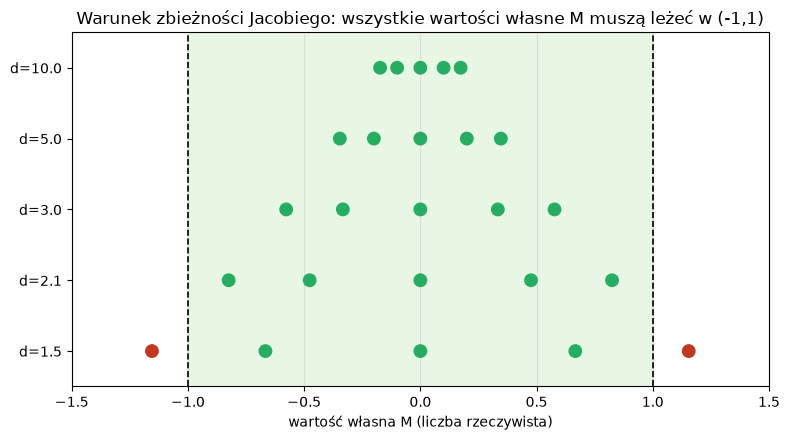

In [3]:
d_values_linia = [1.5, 2.1, 3, 5, 10]

plt.figure(figsize=(8, 4.5))
plt.axvspan(-1, 1, color='#d9f0d3', alpha=0.6, zorder=0)
plt.axvline(-1, color='black', linestyle='--', linewidth=1.2)
plt.axvline(1, color='black', linestyle='--', linewidth=1.2)

for k, d in enumerate(d_values_linia, start=1):
    Ad = macierz_trojdiagonalna(n, d)
    Dd = np.diag(np.diag(Ad))
    LplusUd = Ad - Dd
    Mj = -np.linalg.inv(Dd) @ LplusUd
    ev = np.linalg.eigvals(Mj).real
    zbiega = np.all(np.abs(ev) < 1)
    status = 'ZBIEGA' if zbiega else 'NIE ZBIEGA'
    # Kolor KAZDEGO punktu osobno wg jego wlasnej wartosci bezwzglednej --
    # nie catej "kategorii wiersza" -- bo to jedna JEDNA wartosc wlasna
    # poza pasem juz wystarcza, by cala metoda przestala zbiegac, mimo ze
    # pozostale wartosci wlasne moga wciaz lezec w bezpiecznym przedziale.
    kolory = ['#26ad61' if abs(e) < 1 else '#bf381f' for e in ev]
    plt.scatter(ev, [k] * len(ev), s=80, c=kolory, zorder=3)
    print(f"d={d:.1f}: wartosci wlasne M = {np.round(ev, 3)}  ->  rho(M)={max(abs(ev)):.4f}  ->  {status}")

plt.yticks(range(1, len(d_values_linia) + 1), [f'd={d:.1f}' for d in d_values_linia])
plt.xlabel('wartość własna M (liczba rzeczywista)')
plt.xlim(-1.5, 1.5)
plt.ylim(0.5, len(d_values_linia) + 0.5)
plt.title('Warunek zbieżności Jacobiego: wszystkie wartości własne M muszą leżeć w (-1,1)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Widać to bezpośrednio: dla $d=1.5$ dwie wartości własne ($\pm1.1547$) wypadają **poza** zielonym pasem $(-1,1)$ — Jacobi na tej macierzy nie zbiega, mimo że metoda jest ta sama, zmieniły się tylko dane (macierz $A$). Dla $d=2.1$ i większych wszystkie wartości własne mieszczą się w pasie — im dalej od granicy $\pm1$, tym szybsza zbieżność (patrz następna sekcja, gdzie mierzymy to już liczbą iteracji). Zauważ, że kolorujemy **każdy punkt osobno** wg jego własnej wartości bezwzględnej, nie cały wiersz na raz — bo to jedna jedyna wartość własna poza pasem już wystarcza, by cała metoda przestała zbiegać, mimo że pozostałe wartości własne (te wciąż zielone w wierszu $d=1.5$) same w sobie byłyby bezpieczne.

### Sprawdzenie warunku wystarczającego: dominacja przekątniowa wiersz po wierszu

$\rho(M)<1$ wymaga policzenia wartości własnych — kosztowne dla dużych macierzy. W praktyce często używa się taniego testu **wystarczającego** (nie koniecznego): macierz jest silnie dominująca przekątniowo, jeśli w **każdym** wierszu wartość bezwzględna elementu na przekątnej przewyższa sumę wartości bezwzględnych pozostałych elementów tego wiersza. To standardowy warunek dla Jacobiego/Gaussa-Seidla — prosty test bez liczenia jakichkolwiek wartości własnych.

In [4]:
print("Test dominacji przekątniowej dla macierzy bazowej A:")
for i in range(n):
    diag_elem = abs(A[i, i])
    suma_reszty = np.sum(np.abs(A[i, :])) - diag_elem
    wynik = 'OK' if diag_elem > suma_reszty else 'BRAK'
    print(f"  wiersz {i+1}: |{diag_elem:.2f}| vs suma reszty {suma_reszty:.2f}  ->  {wynik}")

A_slaba = macierz_trojdiagonalna(n, 1.5)
print("\nTest dominacji przekątniowej dla A (d=1.5, wiemy że Jacobi NIE zbiega):")
for i in range(n):
    diag_elem = abs(A_slaba[i, i])
    suma_reszty = np.sum(np.abs(A_slaba[i, :])) - diag_elem
    wynik = 'OK' if diag_elem > suma_reszty else 'BRAK'
    print(f"  wiersz {i+1}: |{diag_elem:.2f}| vs suma reszty {suma_reszty:.2f}  ->  {wynik}")

Test dominacji przekątniowej dla macierzy bazowej A:
  wiersz 1: |3.00| vs suma reszty 1.30  ->  OK
  wiersz 2: |3.00| vs suma reszty 2.30  ->  OK
  wiersz 3: |3.00| vs suma reszty 2.60  ->  OK
  wiersz 4: |3.00| vs suma reszty 2.30  ->  OK
  wiersz 5: |3.00| vs suma reszty 1.30  ->  OK

Test dominacji przekątniowej dla A (d=1.5, wiemy że Jacobi NIE zbiega):
  wiersz 1: |1.50| vs suma reszty 1.00  ->  OK
  wiersz 2: |1.50| vs suma reszty 2.00  ->  BRAK
  wiersz 3: |1.50| vs suma reszty 2.00  ->  BRAK
  wiersz 4: |1.50| vs suma reszty 2.00  ->  BRAK
  wiersz 5: |1.50| vs suma reszty 1.00  ->  OK


Wynik jest pouczający: wiersze **brzegowe** (1 i $n$, mające tylko jednego sąsiada zamiast dwóch) test przechodzą ($1.5>1.0$), ale wiersze **wewnętrzne** — nie ($1.5<2.0$, dwaj sąsiedzi o wadze 1 każdy). Test dominacji przekątniowej trzeba więc spełnić w **każdym** wierszu naraz, żeby cokolwiek gwarantować — jeden zły wiersz wystarczy, żeby założenie upadło (dokładnie tak samo jak przy wartościach własnych wyżej: jedna zła wartość psuje całą metodę). I znowu: to warunek tylko **wystarczający**, nie konieczny — brak dominacji przekątniowej sam w sobie **nie** dowodzi rozbieżności, tu akurat się z nią pokrywa.

### Ten sam wzór, różne dane: czy zbieżność faktycznie zależy tylko od $A$?

Sprawdźmy to bezpośrednio. Weźmy kilka macierzy $A$ z tej samej rodziny (`macierz_trojdiagonalna`, różne $d$), za każdym razem dobierając $b$ tak, żeby dokładne rozwiązanie było tym samym wektorem jedynek, i startując z tego samego punktu $x_0$. Jedyne, co się zmienia, to macierz $A$ -- jeśli liczba iteracji zależy tylko od danych, to różnice w szybkości muszą wynikać wyłącznie z $\rho(M_J)$, a nie z $x_0$ ani z rozwiązania.

d=2.1: ρ(M_Jacobi)=0.8248  ->  124 iteracji
d=2.5: ρ(M_Jacobi)=0.6928  ->  65 iteracji
d=3: ρ(M_Jacobi)=0.5774  ->  44 iteracji
d=5: ρ(M_Jacobi)=0.3464  ->  23 iteracji
d=10: ρ(M_Jacobi)=0.1732  ->  14 iteracji


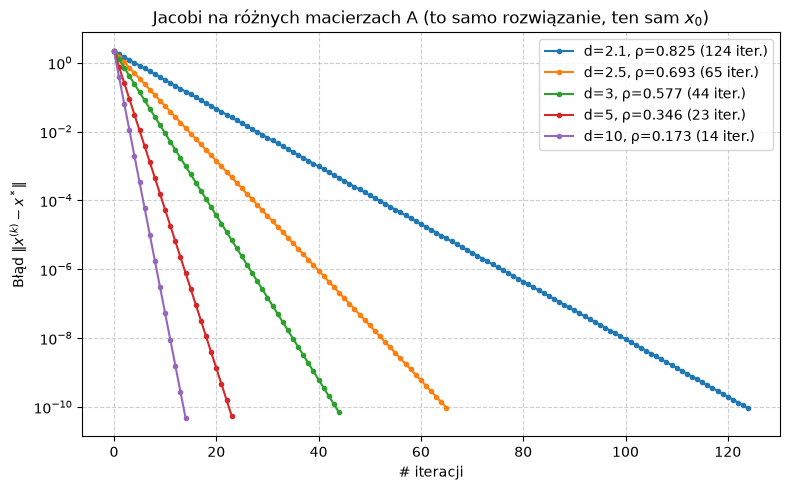

In [5]:
d_values = [2.1, 2.5, 3, 5, 10]   # od słabej (bliżej 2) do silnej (10) dominacji przekątnej; d=2.5 to nasz "bazowy" przykład powyżej
i_max_sweep = 300

plt.figure(figsize=(8, 5))
for d in d_values:
    Ad = macierz_trojdiagonalna(n, d)
    bd = Ad.sum(axis=1)              # b dobrane tak samo dla każdego d -- rozwiązanie zawsze x_dokl = jedynki
    Dd = np.diag(np.diag(Ad))
    Ld_plus_Ud = Ad - Dd

    x = x0.copy()                    # ten sam punkt startowy dla każdego d
    err = [np.linalg.norm(x - x_dokl)]
    for _ in range(i_max_sweep):
        if err[-1] < delta0:
            break
        x = np.linalg.solve(Dd, bd - Ld_plus_Ud @ x)
        err.append(np.linalg.norm(x - x_dokl))

    Mj = -np.linalg.inv(Dd) @ Ld_plus_Ud
    rho = np.max(np.abs(np.linalg.eigvals(Mj)))
    plt.semilogy(err, 'o-', markersize=3, label=f'd={d}, ρ={rho:.3f} ({len(err) - 1} iter.)')
    print(f"d={d}: ρ(M_Jacobi)={rho:.4f}  ->  {len(err) - 1} iteracji")

plt.xlabel('# iteracji')
plt.ylabel('Błąd $\\|x^{(k)} - x^*\\|$')
plt.title('Jacobi na różnych macierzach A (to samo rozwiązanie, ten sam $x_0$)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Metoda Richardsona

W przeciwieństwie do Jacobiego, tutaj **świadomie wprowadzamy dodatkowy parametr** $p$ — nie wynika on z rozkładu macierzy $A$ na $D$, $L$, $U$, tylko z naszego wyboru. Wzór iteracyjny to $x^{(i+1)} = (I - pA)x^{(i)} + pb$, więc macierz iteracyjna to $M = I - pA$.

Ponieważ nasza macierz $A$ jest symetryczna dodatnio określona, promień spektralny $M$ jest najmniejszy dla

$$p_{opt} = \frac{2}{\lambda_{min} + \lambda_{max}}$$

i wtedy zachodzi $\rho(M) = \dfrac{cond(A) - 1}{cond(A) + 1}$. To pierwszy przypadek w tym notebooku, gdzie promieniem spektralnym da się **świadomie sterować**, a nie tylko go policzyć po fakcie.

In [6]:
# Wartości własne A (rzeczywiste, bo A jest symetryczna) -- z nich liczymy optymalne p
# wg wzoru z konspektu: p_opt = 2 / (lambda_min + lambda_max).
eigs_A = np.linalg.eigvalsh(A)
lam_min, lam_max = eigs_A[0], eigs_A[-1]
p_opt = 2 / (lam_min + lam_max)
cond_A = lam_max / lam_min
rho_richardson = (cond_A - 1) / (cond_A + 1)   # wzór teoretyczny dla A symetrycznej
print(f"λ_min={lam_min:.4f}, λ_max={lam_max:.4f}  ->  p_opt={p_opt:.4f}, ρ(I - pA)={rho_richardson:.4f}")

x = x0.copy()
err_richardson = [np.linalg.norm(x - x_dokl)]
for _ in range(i_max):
    if err_richardson[-1] < delta0:
        break
    x = x + p_opt * (b - A @ x)   # x^(i+1) = (I - pA) x^(i) + pb, zapisane bez jawnego (I - pA)
    err_richardson.append(np.linalg.norm(x - x_dokl))

print(f"Richardson (p={p_opt:.4f}): {len(err_richardson) - 1} iteracji do zbieżności")

λ_min=0.9131, λ_max=4.3926  ->  p_opt=0.3770, ρ(I - pA)=0.6558
Richardson (p=0.3770): 57 iteracji do zbieżności


### Ten sam układ, różne $p$: do czego właściwie służy ten parametr?

Tym razem odwrotnie niż przy Jacobim: macierz $A$ i wektor $b$ zostają **te same** (nasz bazowy przykład powyżej), zmienia się tylko $p$. Sprawdźmy kilka wartości wokół $p_{opt}$ -- zarówno mniejszych, jak i większych -- żeby zobaczyć, że $p_{opt}$ rzeczywiście minimalizuje $\rho(M)$, a więc i liczbę iteracji, oraz że zbyt duże $p$ może w ogóle zepsuć zbieżność.

p=0.1131 (0.3·p_opt): ρ(I-pA)=0.8967  ->  zbiegła, 219 iteracji w wykresie
p=0.2262 (0.6·p_opt): ρ(I-pA)=0.7935  ->  zbiegła, 103 iteracji w wykresie
p=0.3770 (1.0·p_opt): ρ(I-pA)=0.6558  ->  zbiegła, 57 iteracji w wykresie
p=0.5277 (1.4·p_opt): ρ(I-pA)=1.3181  ->  ROZBIEGA, 35 iteracji w wykresie
p=0.6785 (1.8·p_opt): ρ(I-pA)=1.9805  ->  ROZBIEGA, 14 iteracji w wykresie


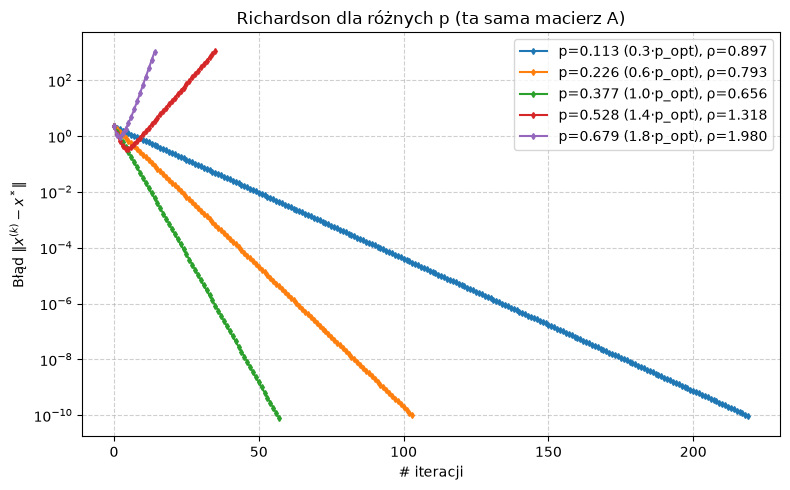

In [7]:
p_factors = [0.3, 0.6, 1.0, 1.4, 1.8]   # ułamki/wielokrotności p_opt (1.0 = wartość optymalna)
i_max_sweep = 300

plt.figure(figsize=(8, 5))
for factor in p_factors:
    p = factor * p_opt
    M = np.eye(n) - p * A
    rho = np.max(np.abs(np.linalg.eigvals(M)))

    x = x0.copy()
    err = [np.linalg.norm(x - x_dokl)]
    for _ in range(i_max_sweep):
        if err[-1] < delta0 or err[-1] > 1e3:   # 1e3: metoda wyraźnie rozbiega, nie ma sensu liczyć dalej
            break
        x = x + p * (b - A @ x)
        err.append(np.linalg.norm(x - x_dokl))

    status = "zbiegła" if err[-1] < delta0 else "ROZBIEGA"
    plt.semilogy(err, 'd-', markersize=3, label=f'p={p:.3f} ({factor}·p_opt), ρ={rho:.3f}')
    print(f"p={p:.4f} ({factor}·p_opt): ρ(I-pA)={rho:.4f}  ->  {status}, {len(err) - 1} iteracji w wykresie")

plt.xlabel('# iteracji')
plt.ylabel('Błąd $\\|x^{(k)} - x^*\\|$')
plt.title('Richardson dla różnych p (ta sama macierz A)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Metoda Gaussa-Seidla

Różnica względem Jacobiego: przy liczeniu współrzędnej $x_i$ używamy **już zaktualizowanych** wartości $x_1, \dots, x_{i-1}$ z bieżącej iteracji, a nie tylko wartości ze starej iteracji.

Tak jak Jacobi, Gauss-Seidel **nie ma żadnego parametru do regulacji** — kolejność aktualizacji współrzędnych jest z góry ustalona przez sam wzór metody, więc $\rho(M_{GS})$ również zależy wyłącznie od $A$. Dopiero SOR (niżej) doda parametr $\omega$ — analogicznie do $p$ w Richardsonie.

In [8]:
x = x0.copy()
err_gs = [np.linalg.norm(x - x_dokl)]
for _ in range(i_max):
    if err_gs[-1] < delta0:
        break
    x_old = x.copy()
    for i in range(n):
        # A[i, :i] @ x[:i]      -- część z już zaktualizowanymi wartościami (bieżąca iteracja)
        # A[i, i+1:] @ x_old[i+1:] -- część ze starymi wartościami (poprzednia iteracja)
        sigma = A[i, :i] @ x[:i] + A[i, i + 1:] @ x_old[i + 1:]
        x[i] = (b[i] - sigma) / A[i, i]
    err_gs.append(np.linalg.norm(x - x_dokl))

# Macierz iteracyjna Gaussa-Seidla M = -(D+L)^{-1} U -- podobnie jak w Jacobim, żadnego
# parametru do wyboru: rho(M_GS) wynika wyłącznie z A.
M_gs = -np.linalg.inv(D + L) @ U
rho_gs = np.max(np.abs(np.linalg.eigvals(M_gs)))
print(f"Gauss-Seidel: {len(err_gs) - 1} iteracji do zbieżności  (ρ(M_GS) = {rho_gs:.4f}, zależne tylko od A)")

Gauss-Seidel: 34 iteracji do zbieżności  (ρ(M_GS) = 0.4897, zależne tylko od A)


### To samo pytanie co dla Jacobiego: różne $A$, ten sam $x_0$ i rozwiązanie

Powtórzmy dokładnie ten sam eksperyment co przy Jacobim, tylko metodą Gaussa-Seidla, na tych samych macierzach `d_values`. Zobaczymy dwie rzeczy naraz: że liczba iteracji znowu zależy tylko od $A$, i że Gauss-Seidel jest przy tym systematycznie szybszy niż Jacobi na każdej z tych macierzy.

d=2.1: ρ(M_GS)=0.6803  ->  63 iteracji
d=2.5: ρ(M_GS)=0.4800  ->  34 iteracji
d=3: ρ(M_GS)=0.3333  ->  23 iteracji
d=5: ρ(M_GS)=0.1200  ->  13 iteracji
d=10: ρ(M_GS)=0.0300  ->  9 iteracji


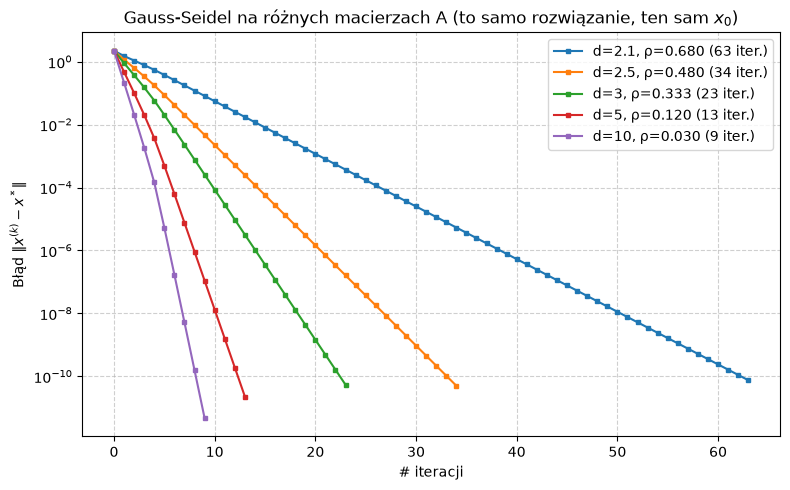

In [9]:
plt.figure(figsize=(8, 5))
for d in d_values:
    Ad = macierz_trojdiagonalna(n, d)
    bd = Ad.sum(axis=1)
    Dd = np.diag(np.diag(Ad))
    Ld = np.tril(Ad, k=-1)
    Ud = np.triu(Ad, k=1)

    x = x0.copy()
    err = [np.linalg.norm(x - x_dokl)]
    for _ in range(i_max_sweep):
        if err[-1] < delta0:
            break
        x_old = x.copy()
        for i in range(n):
            sigma = Ad[i, :i] @ x[:i] + Ad[i, i + 1:] @ x_old[i + 1:]
            x[i] = (bd[i] - sigma) / Ad[i, i]
        err.append(np.linalg.norm(x - x_dokl))

    Mgs = -np.linalg.inv(Dd + Ld) @ Ud
    rho = np.max(np.abs(np.linalg.eigvals(Mgs)))
    plt.semilogy(err, 's-', markersize=3, label=f'd={d}, ρ={rho:.3f} ({len(err) - 1} iter.)')
    print(f"d={d}: ρ(M_GS)={rho:.4f}  ->  {len(err) - 1} iteracji")

plt.xlabel('# iteracji')
plt.ylabel('Błąd $\\|x^{(k)} - x^*\\|$')
plt.title('Gauss-Seidel na różnych macierzach A (to samo rozwiązanie, ten sam $x_0$)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Metoda SOR (Successive Over-Relaxation)

SOR wprowadza dodatkowy parametr $\omega$, który "przeskalowuje" krok Gaussa-Seidla — dokładnie w tym samym duchu, w jakim Richardson wprowadził parametr $p$: to świadomie regulowane "pokrętło", którym można zmniejszyć promień spektralny macierzy iteracyjnej, a nie coś wynikającego wyłącznie z $A$. Dla tej klasy macierzy (tridiagonalnych, o dodatnio określonej strukturze) istnieje wzór na optymalne $\omega$ wyrażony przez promień spektralny macierzy iteracyjnej Jacobiego $\rho(M_J)$:

$$\omega_{opt} = \frac{2}{1 + \sqrt{1 - \rho(M_J)^2}}$$

In [10]:
# rho_jacobi zostało już policzone w sekcji Jacobiego -- tu tylko korzystamy z niego,
# żeby wyznaczyć optymalne omega.
omega = 2 / (1 + np.sqrt(1 - rho_jacobi ** 2))
print(f"ρ(Jacobi) = {rho_jacobi:.4f}  ->  ω_opt ≈ {omega:.4f}")

x = x0.copy()
err_sor = [np.linalg.norm(x - x_dokl)]
for _ in range(i_max):
    if err_sor[-1] < delta0:
        break
    x_old = x.copy()
    for i in range(n):
        sigma = A[i, :i] @ x[:i] + A[i, i + 1:] @ x_old[i + 1:]
        x[i] = (1 - omega) * x_old[i] + (omega / A[i, i]) * (b[i] - sigma)
    err_sor.append(np.linalg.norm(x - x_dokl))

# Macierz iteracyjna SOR M = (D+wL)^{-1}((1-w)D - wU) -- rho(M) tutaj zależy nie tylko od A,
# ale też od naszego wyboru omega.
M_sor = np.linalg.inv(D + omega * L) @ ((1 - omega) * D - omega * U)
rho_sor = np.max(np.abs(np.linalg.eigvals(M_sor)))
print(f"SOR (ω={omega:.4f}): {len(err_sor) - 1} iteracji do zbieżności  (ρ(M_SOR) = {rho_sor:.4f})")

ρ(Jacobi) = 0.6956  ->  ω_opt ≈ 1.1639
SOR (ω=1.1639): 19 iteracji do zbieżności  (ρ(M_SOR) = 0.2504)


### Ten sam układ, różne $\omega$: dokładnie ta sama logika co przy Richardsonie

Macierz $A$ i $b$ znowu te same, zmienia się tylko $\omega$. $\omega=1$ to dokładnie zwykły Gauss-Seidel (bez "podkręcenia") -- dobry punkt odniesienia, żeby zobaczyć, ile faktycznie daje dobranie $\omega_{opt}$.

ω=0.5000: ρ(M_SOR)=0.8140  ->  116 iteracji
ω=1.0000: ρ(M_SOR)=0.4897  ->  34 iteracji
ω=1.1639: ρ(M_SOR)=0.2504  ->  19 iteracji
ω=1.5000: ρ(M_SOR)=0.5459  ->  38 iteracji
ω=1.9000: ρ(M_SOR)=0.9113  ->  242 iteracji


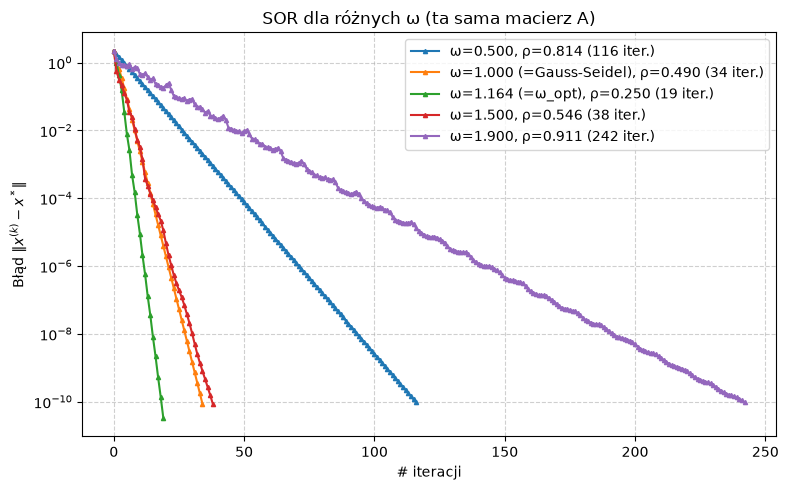

In [11]:
omega_values = [0.5, 1.0, omega, 1.5, 1.9]   # 1.0 = zwykły Gauss-Seidel, `omega` = wartość optymalna z komórki wyżej
i_max_sweep = 300

plt.figure(figsize=(8, 5))
for w in omega_values:
    Msor = np.linalg.inv(D + w * L) @ ((1 - w) * D - w * U)
    rho = np.max(np.abs(np.linalg.eigvals(Msor)))

    x = x0.copy()
    err = [np.linalg.norm(x - x_dokl)]
    for _ in range(i_max_sweep):
        if err[-1] < delta0:
            break
        x_old = x.copy()
        for i in range(n):
            sigma = A[i, :i] @ x[:i] + A[i, i + 1:] @ x_old[i + 1:]
            x[i] = (1 - w) * x_old[i] + (w / A[i, i]) * (b[i] - sigma)
        err.append(np.linalg.norm(x - x_dokl))

    etykieta = f'ω={w:.3f}' + (' (=Gauss-Seidel)' if w == 1.0 else '') + (' (=ω_opt)' if w == omega else '')
    plt.semilogy(err, '^-', markersize=3, label=f'{etykieta}, ρ={rho:.3f} ({len(err) - 1} iter.)')
    print(f"ω={w:.4f}: ρ(M_SOR)={rho:.4f}  ->  {len(err) - 1} iteracji")

plt.xlabel('# iteracji')
plt.ylabel('Błąd $\\|x^{(k)} - x^*\\|$')
plt.title('SOR dla różnych ω (ta sama macierz A)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Porównanie na jednym wykresie

Wracamy do pojedynczych, "optymalnych" przebiegów każdej z metod (te same `err_jacobi`, `err_richardson`, `err_gs`, `err_sor` policzone wyżej), żeby zobaczyć wszystkie cztery obok siebie.

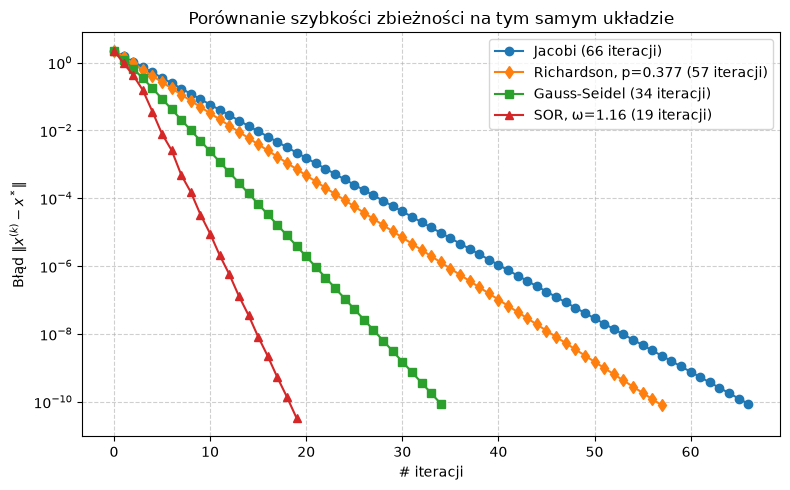

Metoda               ρ(M)   Liczba iteracji
Jacobi             0.6956                66
Richardson         0.6558                57
Gauss-Seidel       0.4897                34
SOR (ω_opt)        0.2504                19


In [12]:
plt.figure(figsize=(8, 5))
plt.semilogy(err_jacobi, 'o-', label=f'Jacobi ({len(err_jacobi) - 1} iteracji)')
plt.semilogy(err_richardson, 'd-', label=f'Richardson, p={p_opt:.3f} ({len(err_richardson) - 1} iteracji)')
plt.semilogy(err_gs, 's-', label=f'Gauss-Seidel ({len(err_gs) - 1} iteracji)')
plt.semilogy(err_sor, '^-', label=f'SOR, ω={omega:.2f} ({len(err_sor) - 1} iteracji)')
plt.xlabel('# iteracji')
plt.ylabel('Błąd $\\|x^{(k)} - x^*\\|$')
plt.title('Porównanie szybkości zbieżności na tym samym układzie')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"{'Metoda':<15}{'ρ(M)':>10}{'Liczba iteracji':>18}")
print(f"{'Jacobi':<15}{rho_jacobi:>10.4f}{len(err_jacobi) - 1:>18}")
print(f"{'Richardson':<15}{rho_richardson:>10.4f}{len(err_richardson) - 1:>18}")
print(f"{'Gauss-Seidel':<15}{rho_gs:>10.4f}{len(err_gs) - 1:>18}")
print(f"{'SOR (ω_opt)':<15}{rho_sor:>10.4f}{len(err_sor) - 1:>18}")

## Najważniejsze wnioski

- Wszystkie cztery metody zbiegają do tego samego rozwiązania na tym samym układzie -- różni je tylko **liczba iteracji** potrzebna do osiągnięcia tej samej dokładności, a to sprowadza się zawsze do jednej wielkości: promienia spektralnego $\rho(M)$ macierzy iteracyjnej -- im mniejszy, tym szybciej.
- **Jacobi i Gauss-Seidel nie mają żadnego parametru do regulacji** -- $\rho(M)$ wynika wyłącznie z danych (macierzy $A$). Sweepy powyżej pokazują to wprost: dla tej samej metody i tego samego $x_0$, jedyne co zmienia liczbę iteracji, to wybór $A$.
- **Richardson i SOR świadomie wprowadzają dodatkowy parametr** ($p$, odpowiednio $\omega$), którym można sterować $\rho(M)$ -- też pokazane wprost: ta sama macierz $A$, a liczba iteracji zmienia się drastycznie w zależności tylko od wyboru parametru. Widać też koszt tej kontroli: źle dobrany parametr (zbyt duże $p$ czy $\omega$ poza $(0,2)$) może dać wynik gorszy niż metoda bezparametrowa, a nawet w ogóle zepsuć zbieżność.
- Zwróć uwagę, że nasza macierz bazowa (`macierz_pieciodiagonalna`) ma dodatkowe, słabsze sprzężenie "co drugi element" -- nie jest to czysto trójdiagonalna macierz jak w sekcjach sweepów wyżej. Dla czysto trójdiagonalnej macierzy o stałej przekątnej zachodzi dokładna tożsamość $\rho(\text{Richardson}_{opt}) = \rho(M_{Jacobi})$ (można to sprawdzić algebraicznie), więc Richardson nie miałby tam żadnej przewagi -- tylko możliwość dorównania Jacobiemu. Dodatkowe sprzężenie tę tożsamość przełamuje: w porównaniu niżej Richardson faktycznie zbiega szybciej niż Jacobi, choć wciąż wyraźnie wolniej niż Gauss-Seidel czy SOR (parametr pomaga, ale nie zmienia rzędu metody).
- Gauss-Seidel zwykle potrzebuje wyraźnie mniej iteracji niż Jacobi (używa już zaktualizowanych wartości w tej samej iteracji), mimo że żadna z tych dwóch metod nie ma parametru do wyboru -- różnica wynika wyłącznie z konstrukcji wzoru.
- SOR z dobrze dobranym $\omega$ zbiega jeszcze szybciej niż Gauss-Seidel — ale (patrz ćwiczenie niżej) tylko dla **odpowiedniego zakresu** $\omega$; źle dobrane $\omega$ może dać wynik gorszy niż zwykły Gauss-Seidel, a poza $(0,2)$ metoda w ogóle nie zbiega.

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.diag(v, k)` | Tworzy macierz diagonalną z wektora `v` na $k$-tej przekątnej |
| `np.tril(A, k)` / `np.triu(A, k)` | Dolna / górna część macierzy $A$ (bez głównej przekątnej przy `k=-1`/`k=1`) |
| `np.linalg.solve(A, b)` | Rozwiązuje układ $Ax=b$ |
| `np.linalg.eigvals(A)` | Wartości własne macierzy $A$ (ogólnej) |
| `np.linalg.eigvalsh(A)` | Wartości własne macierzy symetrycznej $A$ (szybsze i dokładniejsze niż `eigvals` dla tego przypadku) |
| `np.linalg.norm(x)` | Norma euklidesowa wektora |

## ĆWICZENIE — wpływ parametru ω w metodzie SOR

Sprawdźmy, jak liczba iteracji potrzebna do zbieżności zależy od wyboru $\omega$ — w tym samym układzie co wyżej.

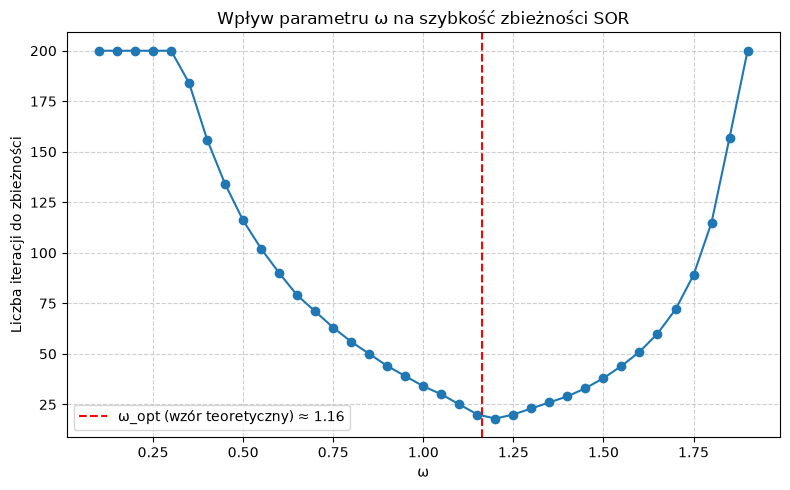

Najlepsze ω znalezione w siatce: 1.20 (teoretyczne ω_opt: 1.1639) -- zgodność potwierdza wzór z konspektu.


In [13]:
def sor_liczba_iteracji(A, b, x0, omega, x_dokl, delta0=1e-10, i_max=200):
    # Zwraca liczbę iteracji SOR potrzebną do osiągnięcia zadanej dokładności
    # (albo i_max, jeśli metoda nie zbiegła w tylu krokach -- np. dla omega spoza (0,2)).
    n = len(b)
    x = x0.copy()
    err = np.linalg.norm(x - x_dokl)
    for k in range(1, i_max + 1):
        if err < delta0:
            return k - 1
        x_old = x.copy()
        for i in range(n):
            sigma = A[i, :i] @ x[:i] + A[i, i + 1:] @ x_old[i + 1:]
            x[i] = (1 - omega) * x_old[i] + (omega / A[i, i]) * (b[i] - sigma)
        err = np.linalg.norm(x - x_dokl)
        if not np.isfinite(err):     # metoda rozbiega -- przerywamy wcześniej
            return i_max
    return i_max

omegi = np.arange(0.1, 1.95, 0.05)
iteracje = [sor_liczba_iteracji(A, b, x0, w, x_dokl) for w in omegi]

plt.figure(figsize=(8, 5))
plt.plot(omegi, iteracje, 'o-')
plt.axvline(omega, color='r', linestyle='--', label=f'ω_opt (wzór teoretyczny) ≈ {omega:.2f}')
plt.xlabel('ω')
plt.ylabel('Liczba iteracji do zbieżności')
plt.title('Wpływ parametru ω na szybkość zbieżności SOR')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

omega_najlepsze = omegi[np.argmin(iteracje)]
print(f"Najlepsze ω znalezione w siatce: {omega_najlepsze:.2f} "
      f"(teoretyczne ω_opt: {omega:.4f}) -- zgodność potwierdza wzór z konspektu.")

**Spróbuj samodzielnie**: zmień rozmiar układu `n` albo parametry `d`, `e` w wywołaniu `macierz_pieciodiagonalna(n, d, e)` (np. `d=2.2` dla dużo gorzej uwarunkowanego układu, albo `d=10` dla dużo lepiej -- pamiętaj, `d` musi być > ok. `2 + 2*e`, żeby macierz w ogóle była dominująca przekątniowo) i uruchom ponownie powyższy sweep. Czy położenie optimum $\omega$ się przesuwa? Czy ogólny kształt wykresu (jedno wyraźne minimum) się zachowuje?

## Zastosowanie w praktyce: układ z macierzą rzadką

Powyżej używaliśmy małych, gęstych macierzy $5\times 5$, żeby wszystko było łatwe do policzenia i podejrzenia. Ale **metody iteracyjne wzięły się historycznie właśnie z potrzeby rozwiązywania dużych układów z macierzą rzadką** (rzadką = prawie same zera poza kilkoma niezerowymi wpisami w każdym wierszu) -- najczęściej powstających z dyskretyzacji równań różniczkowych cząstkowych.

Klasyczny przykład: stan ustalony rozkładu temperatury (albo potencjału elektrostatycznego) na kwadratowej płytce, opisany dwuwymiarowym równaniem Poissona, zdyskretyzowanym na siatce $m \times m$ metodą różnic skończonych (schemat "pięciopunktowy"). Powstająca macierz ma rozmiar $n = m^2$, ale w każdym wierszu tylko do 5 niezerowych wpisów -- dla dużego $m$ ogromna większość macierzy to zera.

Budujemy ją tu za pomocą `scipy.sparse`, żeby faktycznie przechowywać tylko niezerowe wartości (macierz gęsta $m^2 \times m^2$ dla dużego $m$ w ogóle nie zmieściłaby się w pamięci) -- i **żadna z metod poniżej nigdy nie odwraca ani nie zagęszcza tej macierzy**: Jacobi dzieli tylko przez przekątną, a SOR/Gauss-Seidel rozwiązują układ trójkątny rzadki (`scipy.sparse.linalg.spsolve_triangular`).

Macierz 400x400 (160,000 elementów), tylko 1,920 niezerowych  ->  gęstość 1.200%
Siatka 20x20: ρ(M_Jacobi) = 0.9888 (analitycznie)  ->  ω_opt = 1.7406
Jacobi (macierz rzadka): 1893 iteracji


SOR ω=1.7406 (macierz rzadka): 87 iteracji


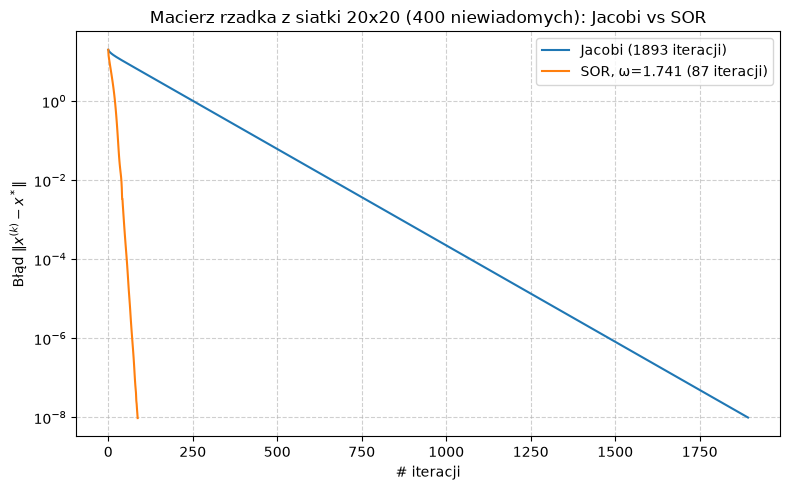

In [14]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

m = 20                              # siatka 20x20 -> n = 400 niewiadomych
n_s = m * m

I_m = sp.identity(m, dtype=float)
# T -- 1D operator różnicowy (d^2/dx^2) na jednym "rzędzie" siatki; L1 -- sprzężenia z sąsiednimi rzędami
T = sp.diags([-1, 4, -1], [-1, 0, 1], shape=(m, m), dtype=float)
L1 = sp.diags([-1, -1], [-1, 1], shape=(m, m), dtype=float)
A_s = (sp.kron(I_m, T) + sp.kron(L1, I_m)).tocsr()   # 2D Laplasjan (schemat 5-punktowy) jako macierz rzadka CSR

gestosc = A_s.nnz / n_s ** 2
print(f"Macierz {n_s}x{n_s} ({n_s**2:,} elementów), tylko {A_s.nnz:,} niezerowych  ->  gęstość {gestosc:.3%}")


Sama liczba (gęstość powyżej) nie pokazuje, **gdzie** dokładnie leżą te nieliczne niezerowe elementy — zobaczmy to wprost na wykresie struktury (spy plot). Uwaga: to jedyne miejsce w całym notatniku, gdzie rysujemy „mapę” macierzy, a nie same liczby — ale tutaj celowo, bo chodzi wyłącznie o **strukturę** (które pozycje są niezerowe), nie o **wartości** (w przeciwieństwie do pivotingu/$cond(A)$/$\rho(M)$ w innych demo, gdzie liczy się konkretna liczba).

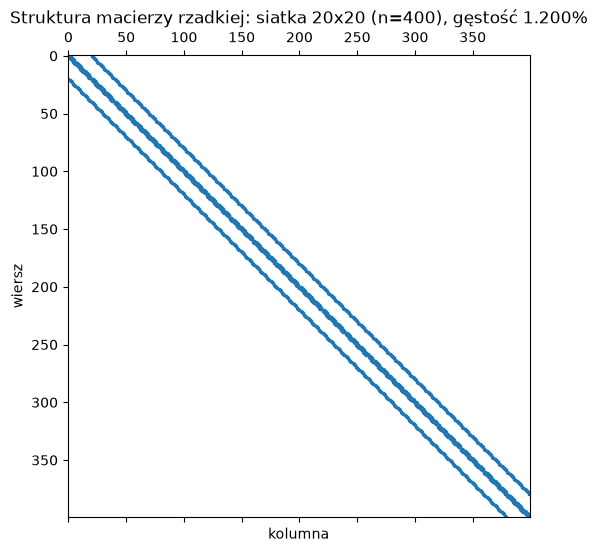

In [15]:
plt.figure(figsize=(6, 6))
plt.spy(A_s, markersize=2)
plt.title(f'Struktura macierzy rzadkiej: siatka {m}x{m} (n={n_s}), gęstość {gestosc:.3%}')
plt.xlabel('kolumna')
plt.ylabel('wiersz')
plt.show()

Widać wyraźne pasmo wokół głównej przekątnej (sąsiedzi w tym samym rzędzie siatki) plus dwie cienkie, odległe o $m$ pozycji przekątne (sąsiedzi w rzędzie powyżej/poniżej) — reszta macierzy to czysta pustka. To właśnie ta struktura pozwala metodom iteracyjnym (Jacobi, SOR) działać tanio na dużych $n_s$: każdy krok to tylko mnożenie $A_s x$, a ono kosztuje tyle, ile jest niezerowych elementów, nie $n_s^2$.

Siatka 20x20: ρ(M_Jacobi) = 0.9888 (analitycznie)  ->  ω_opt = 1.7406
Jacobi (macierz rzadka): 1893 iteracji
SOR ω=1.7406 (macierz rzadka): 87 iteracji


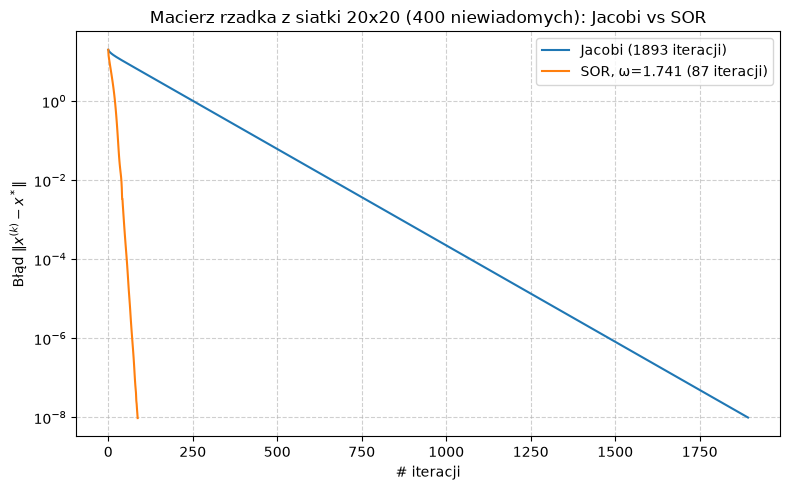

In [16]:
x_dokl_s = np.ones(n_s)             # jak wyżej: b dobrane tak, żeby dokładne rozwiązanie to same jedynki
b_s = A_s @ x_dokl_s
x0_s = np.zeros(n_s)

D_s = A_s.diagonal()                # przekątna jako wektor 1D -- to wystarczy dla Jacobiego
L_s = sp.tril(A_s, k=-1).tocsr()
U_s = sp.triu(A_s, k=1).tocsr()

# Dla siatki Poissona m x m znane jest analityczne rho(M_Jacobi) = cos(pi/(m+1)) -- ta sama
# klasa macierzy "consistently ordered" co nasze przykłady trójdiagonalne wyżej, więc ten sam
# wzór na omega_opt też działa.
rho_j_s = np.cos(np.pi / (m + 1))
omega_s = 2 / (1 + np.sqrt(1 - rho_j_s ** 2))
print(f"Siatka {m}x{m}: ρ(M_Jacobi) = {rho_j_s:.4f} (analitycznie)  ->  ω_opt = {omega_s:.4f}")

delta0_s = 1e-8
i_max_s = 8000

# Jacobi na macierzy rzadkiej: mnożenie A_s @ x jest rzadkie (szybkie), dzielenie przez D_s
# jest elementowe -- ani razu nie tworzymy pełnej (gęstej) macierzy.
x = x0_s.copy()
err_jacobi_s = [np.linalg.norm(x - x_dokl_s)]
while err_jacobi_s[-1] >= delta0_s and len(err_jacobi_s) <= i_max_s:
    x = (b_s - (A_s @ x - D_s * x)) / D_s
    err_jacobi_s.append(np.linalg.norm(x - x_dokl_s))
print(f"Jacobi (macierz rzadka): {len(err_jacobi_s) - 1} iteracji")

# SOR na macierzy rzadkiej: zamiast jawnej odwrotności (D + omega*L) rozwiązujemy układ
# trójkątny rzadki -- to właśnie robi spsolve_triangular, bez zagęszczania niczego.
DL_s = (sp.diags(D_s) + omega_s * L_s).tocsr()
x = x0_s.copy()
err_sor_s = [np.linalg.norm(x - x_dokl_s)]
while err_sor_s[-1] >= delta0_s and len(err_sor_s) <= i_max_s:
    rhs = omega_s * (b_s - U_s @ x) + (1 - omega_s) * D_s * x
    x = spla.spsolve_triangular(DL_s, rhs, lower=True)
    err_sor_s.append(np.linalg.norm(x - x_dokl_s))
print(f"SOR ω={omega_s:.4f} (macierz rzadka): {len(err_sor_s) - 1} iteracji")

plt.figure(figsize=(8, 5))
plt.semilogy(err_jacobi_s, label=f'Jacobi ({len(err_jacobi_s) - 1} iteracji)')
plt.semilogy(err_sor_s, label=f'SOR, ω={omega_s:.3f} ({len(err_sor_s) - 1} iteracji)')
plt.xlabel('# iteracji')
plt.ylabel('Błąd $\\|x^{(k)} - x^*\\|$')
plt.title(f'Macierz rzadka z siatki {m}x{m} ({n_s} niewiadomych): Jacobi vs SOR')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

To właśnie ta różnica -- brak parametru vs. świadomie dobrany $\omega$ -- decyduje w praktyce, czy duży, rzadki układ da się w ogóle rozwiązać w rozsądnym czasie. Zobaczmy jeszcze, jak wygląda samo rozwiązanie: policzmy metodą SOR stan ustalony temperatury przy jednorodnym źródle ciepła w całym obszarze (a nie tylko sztuczny przykład z rozwiązaniem "same jedynki").

Tym razem nie znamy dokładnego rozwiązania z góry, więc kryterium stopu to nie odległość od `x_dokl`, tylko **norma residuum** $\|Ax^{(k)} - b\|$ -- to jest właśnie kryterium używane w praktyce, kiedy dokładnego rozwiązania po prostu nie znamy.

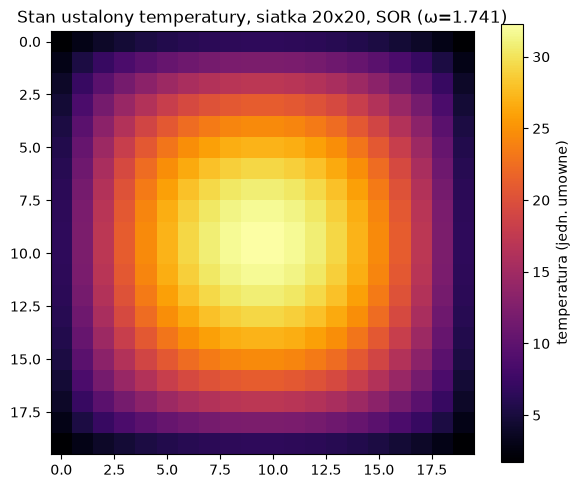

In [17]:
b_cieplo = np.ones(n_s)   # jednorodne źródło ciepła w każdym punkcie siatki; brzeg siatki = temperatura 0 (wynika z konstrukcji A_s)

x = x0_s.copy()
residuum = np.linalg.norm(A_s @ x - b_cieplo)
while residuum >= 1e-8:
    rhs = omega_s * (b_cieplo - U_s @ x) + (1 - omega_s) * D_s * x
    x = spla.spsolve_triangular(DL_s, rhs, lower=True)
    residuum = np.linalg.norm(A_s @ x - b_cieplo)

plt.figure(figsize=(6, 5))
plt.imshow(x.reshape(m, m), cmap='inferno')
plt.colorbar(label='temperatura (jedn. umowne)')
plt.title(f'Stan ustalony temperatury, siatka {m}x{m}, SOR (ω={omega_s:.3f})')
plt.tight_layout()
plt.show()

**Spróbuj samodzielnie**: zwiększ rozmiar siatki `m` (np. do 40 albo 60) i porównaj, jak rośnie przewaga SOR nad Jacobim -- powinieneś zobaczyć, że im większa (rzadsza) macierz, tym bardziej opłaca się mieć kontrolę nad $\rho(M)$ zamiast być zdanym wyłącznie na dane.